# scTopDEC paul15 tutorial

July 2026

Author: Pakorn Sagulkoo

In this code, we performed scTopoDEC testing on a benchmark single-cell dataset, paul15, to evaluate whether the model runs without errors, as well as to tune hyperparameters for optimal clustering performance.

## Import the relevant libraries

In [1]:
# Import the libraries
import scTopoDEC as stc
import keras
import tensorflow as tf
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Check the version of the imported packages
print(f"scTopoDEC version: {stc.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"Tensorflow version: {tf.__version__}")

scTopoDEC version: 0.1.0
Keras version: 3.13.2
Tensorflow version: 2.20.0


## Load the dataset

We use paul15 from scanpy as a benchmark dataet in this code. Further detail of this dataset can be found in this ([link](https://scanpy.readthedocs.io/en/stable/generated/scanpy.datasets.paul15.html))

In [2]:
# Load single-cell dataset
adata = sc.datasets.paul15()

  0%|          | 0.00/9.82M [00:00<?, ?B/s]

We performed some standard single-cell analysis to look overall patterns of the dataset

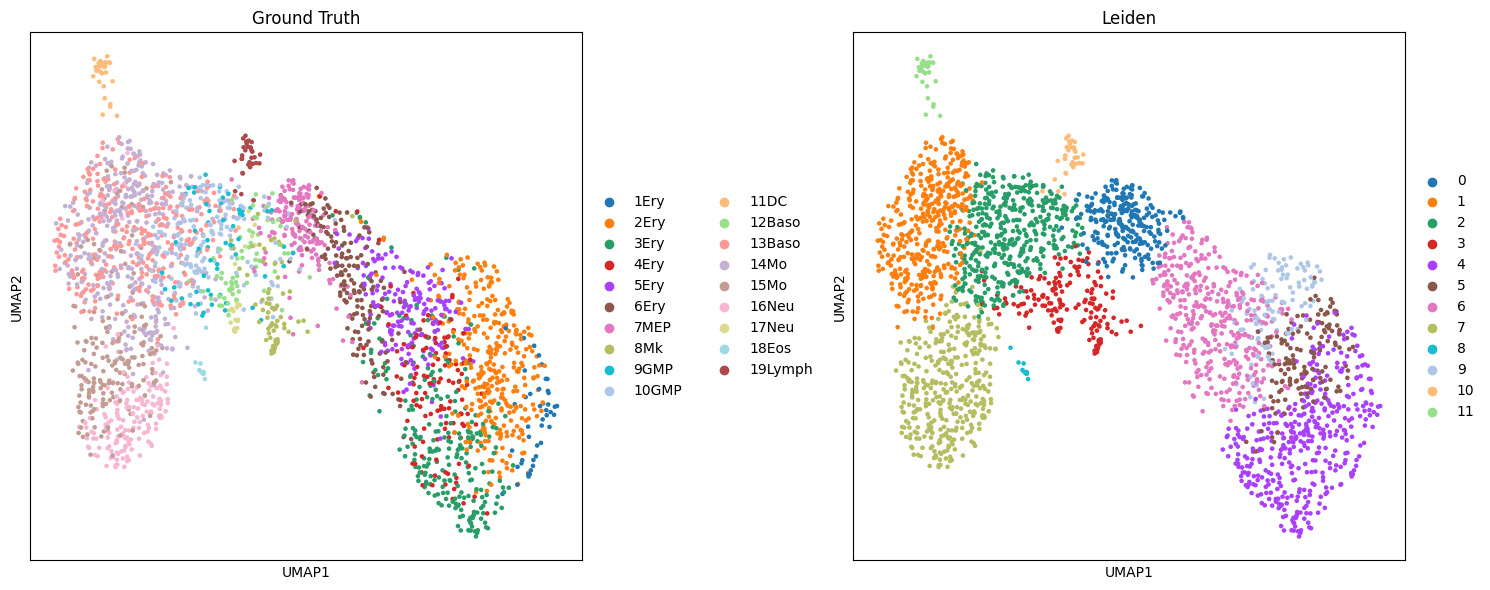

In [3]:
# scRNA-seq standard pipeline analysis
# 1. Quality control
adata_orig = adata.copy()
sc.pp.filter_genes(adata_orig, min_cells=5)
sc.pp.filter_cells(adata_orig, min_counts=5)

# 3. Feature selection
sc.pp.highly_variable_genes(adata_orig, n_top_genes=2000, flavor='seurat_v3')

# 2. Normalisation
adata_orig.layers['counts'] = adata_orig.X.copy() # Saving count data
sc.pp.normalize_total(adata_orig)
sc.pp.log1p(adata_orig)
sc.pp.scale(adata_orig)

# 4. PCA and UMAP
sc.tl.pca(adata_orig)
sc.pp.neighbors(adata_orig)
sc.tl.umap(adata_orig)

# 5. Standard clustering
sc.tl.leiden(adata_orig, flavor="igraph", n_iterations=2)

# 5. Visualisation
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(adata_orig, color='paul15_clusters', ax=ax[0], show=False, title="Ground Truth")
sc.pl.umap(adata_orig, color='leiden', ax=ax[1], show=False, title="Leiden")
plt.tight_layout()
plt.show()

## Run scTopoDEC

Before we run the model, we prepared the data especially the groud truth. We preprocessed the ground truth compatible with our analysis by grouping the same cell types in small clusters into main cell type clusters. We also encoded the string ground truth to make the model can use evalaution metrices to score the dataset.

In [4]:
# scRNA-seq preprocessing for scTopoDEC
# 1. QC
adata_stc = adata.copy()
sc.pp.filter_genes(adata_stc, min_cells=5)
sc.pp.filter_cells(adata_stc, min_counts=5)
adata_stc.layers["counts"] = adata_stc.X.copy() # Saving count data

# 2. Group main cell types
mapping = {
    '1Ery':'Ery', '2Ery':'Ery', '3Ery':'Ery',
    '4Ery':'Ery', '5Ery':'Ery', '6Ery':'Ery',
    '7MEP':'MEP', '8Mk':'Mk', '9GMP':'GMP',
    '10GMP':'GMP', '11DC':'DC', '12Baso':'Baso',
    '13Baso':'Baso', '14Mo':'Mo', '15Mo':'Mo',
    '16Neu':'Neu', '17Neu':'Neu', '18Eos':'Eos',
    '19Lymph':'Lymph'
}

adata_stc.obs['cell_type'] = adata_stc.obs['paul15_clusters'].map(mapping)

# 3. Create a numerical version of your ground truth
le = LabelEncoder()
adata_stc.obs['cell_type_encoded1'] = le.fit_transform(adata_stc.obs['cell_type'])
adata_stc.obs['cell_type_encoded2'] = le.fit_transform(adata_stc.obs['paul15_clusters'])

Now we will run our model. This may take some time, so feel free to grab a cup of coffee or tea while you wait for it to finish.

In [5]:
# Run the model
stc.scTopoDEC(adata_stc, n_clusters=15, loss_weights=(1.0, 1.0, 0.1, 1.0))

Confirmed: adata.X contains raw counts.
DEC mode: Selecting top 2000 highly variable genes...


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:278: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_counts"] = number



...Pretraining Autoencoder...
No pre-trained weights found. Starting fresh pre-training...
Pretraining complete in 79.59 seconds.

...n_clusters is not 0: Initializing cluster centers with k-means...

...Training for clustering...


Training DEC:  77%|███████▋  | 385/500 [1:15:56<22:40, 11.83s/epoch]

Converged at epoch 385: delta 0.0004 < 0.001
Total Clustering Training complete in 4557.35 seconds.


Calculating clustering...
Identified 15 unique clusters.

Algorithm runs successfully!


After the model finishes the running, the final performance is shown here.



In [10]:
# Show the final clustering performance
from scTopoDEC.metric import model_eval
acc, ami, ari, nmi = model_eval(adata_stc, model_clusters='stc_cluster', ground_truth='cell_type_encoded2')
print(f"Clustering performance: ACC={acc}, AMI={ami}, ARI={ari}, NMI={nmi}")

Clustering performance: ACC=0.49707, AMI=0.59793, ARI=0.36603, NMI=0.60553


## Visualise the results

After running the model, we visualised the results and compared them with the ground truth and Leiden clustering, a standard method in single-cell data analysis. We also visualised the latent space learned by our model to compare the distribution of cell embeddings with those obtained using UMAP.

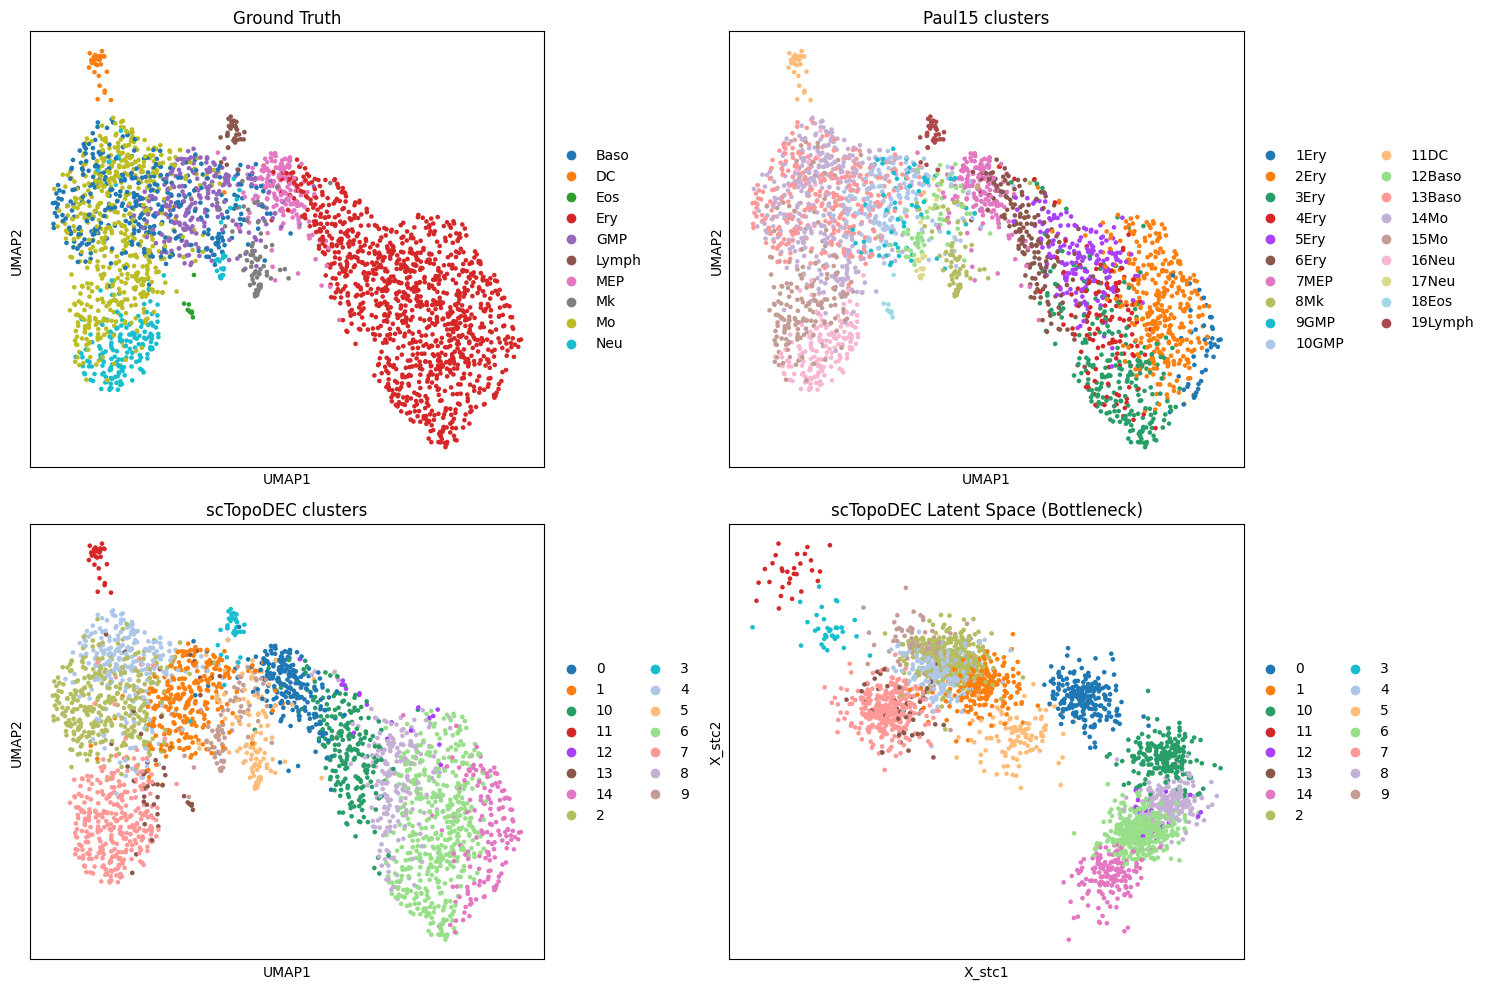

In [8]:
# Data visualisation after the running
adata_stc.X = adata_stc.layers["counts"].copy()

# 1. Prepare all embeddings first
sc.pp.highly_variable_genes(adata_stc, n_top_genes=2000, flavor='seurat_v3')
sc.pp.normalize_total(adata_stc)
sc.pp.log1p(adata_stc)
sc.pp.scale(adata_stc)
sc.tl.pca(adata_stc)
sc.pp.neighbors(adata_stc) # Standard neighbors for UMAP
sc.tl.umap(adata_stc)      # Computes X_umap
sc.tl.leiden(adata_stc, flavor="igraph", n_iterations=2)

# 2. Setup the figure
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# 3. Left Plot: Standard UMAP
sc.pl.umap(adata_stc, color='cell_type', ax=ax[0, 0], show=False, title="Ground Truth")
sc.pl.umap(adata_stc, color='paul15_clusters', ax=ax[0, 1], show=False, title="Paul15 clusters")
sc.pl.umap(adata_stc, color='stc_cluster', ax=ax[1, 0], show=False, title="scTopoDEC clusters")

# 4. Right Plot: scTopoDEC Latent Space
# We plot the embedding directly from the model's bottleneck layer
sc.pl.embedding(adata_stc, basis='X_stc', color='stc_cluster',
                ax=ax[1, 1], show=False, title="scTopoDEC Latent Space (Bottleneck)")

plt.tight_layout()
plt.show()

After that, we measured the clustering performance from the leiden method to compare with our method.

In [11]:
# Show the final clustering performance of the leiden method
acc, ami, ari, nmi = model_eval(adata_stc, model_clusters='leiden', ground_truth='cell_type_encoded2')
print(f"Clustering performance: ACC={acc}, AMI={ami}, ARI={ari}, NMI={nmi}")

Clustering performance: ACC=0.43773, AMI=0.5602, ARI=0.32863, NMI=0.56695


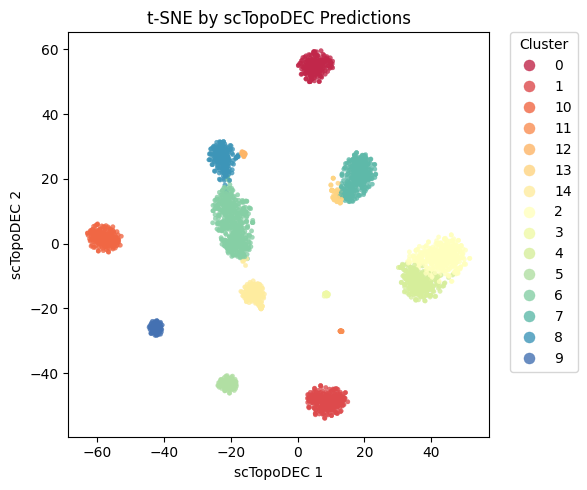

In [12]:
# Cluster plot with seaborn
sc.tl.tsne(adata_stc, use_rep="X_stc", random_state=42)
tsne_coords = adata_stc.obsm['X_tsne']
clusters = adata_stc.obs['stc_cluster']

plt.figure(figsize=(6, 5))

sns.scatterplot(
    x=tsne_coords[:, 0],
    y=tsne_coords[:, 1],
    hue=clusters,
    palette='Spectral',
    s=10,
    alpha=0.8,
    edgecolor=None
)

plt.grid(False)

plt.title('t-SNE by scTopoDEC Predictions')
plt.xlabel('scTopoDEC 1')
plt.ylabel('scTopoDEC 2')

# Create the legend
leg = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Cluster')

# Loop through the legend handles and increase their size
for handle in leg.legend_handles:
    handle._sizes = [50] # For PathCollections
    if hasattr(handle, 'set_markersize'):
        handle.set_markersize(8) # For Line2D (approx size 8-10 is visible)

plt.tight_layout()
plt.show()

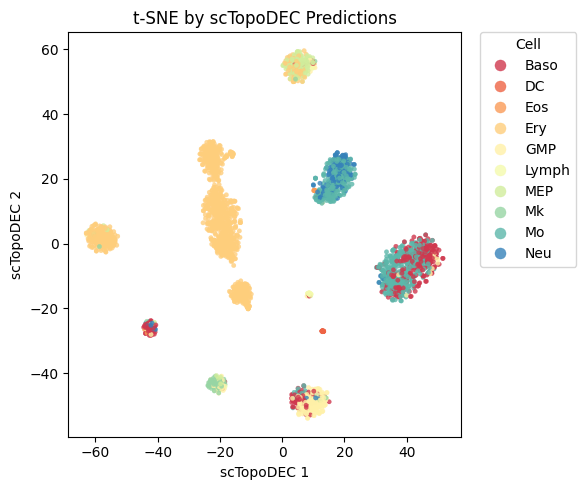

In [14]:
# Cell plot with seaborn
sc.tl.tsne(adata_stc, use_rep="X_stc", random_state=42)
tsne_coords = adata_stc.obsm['X_tsne']
cell = adata_stc.obs['cell_type']

plt.figure(figsize=(6, 5))

sns.scatterplot(
    x=tsne_coords[:, 0],
    y=tsne_coords[:, 1],
    hue=cell,
    palette='Spectral',
    s=10,
    alpha=0.8,
    edgecolor=None
)

plt.grid(False)

plt.title('t-SNE by scTopoDEC Predictions')
plt.xlabel('scTopoDEC 1')
plt.ylabel('scTopoDEC 2')

# Create the legend
leg = plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title='Cell')

# Loop through the legend handles and increase their size
for handle in leg.legend_handles:
    handle._sizes = [50] # For PathCollections
    if hasattr(handle, 'set_markersize'):
        handle.set_markersize(8) # For Line2D (approx size 8-10 is visible)

plt.tight_layout()
plt.show()

Here, we also plotted the probalibility for each identified cluster.

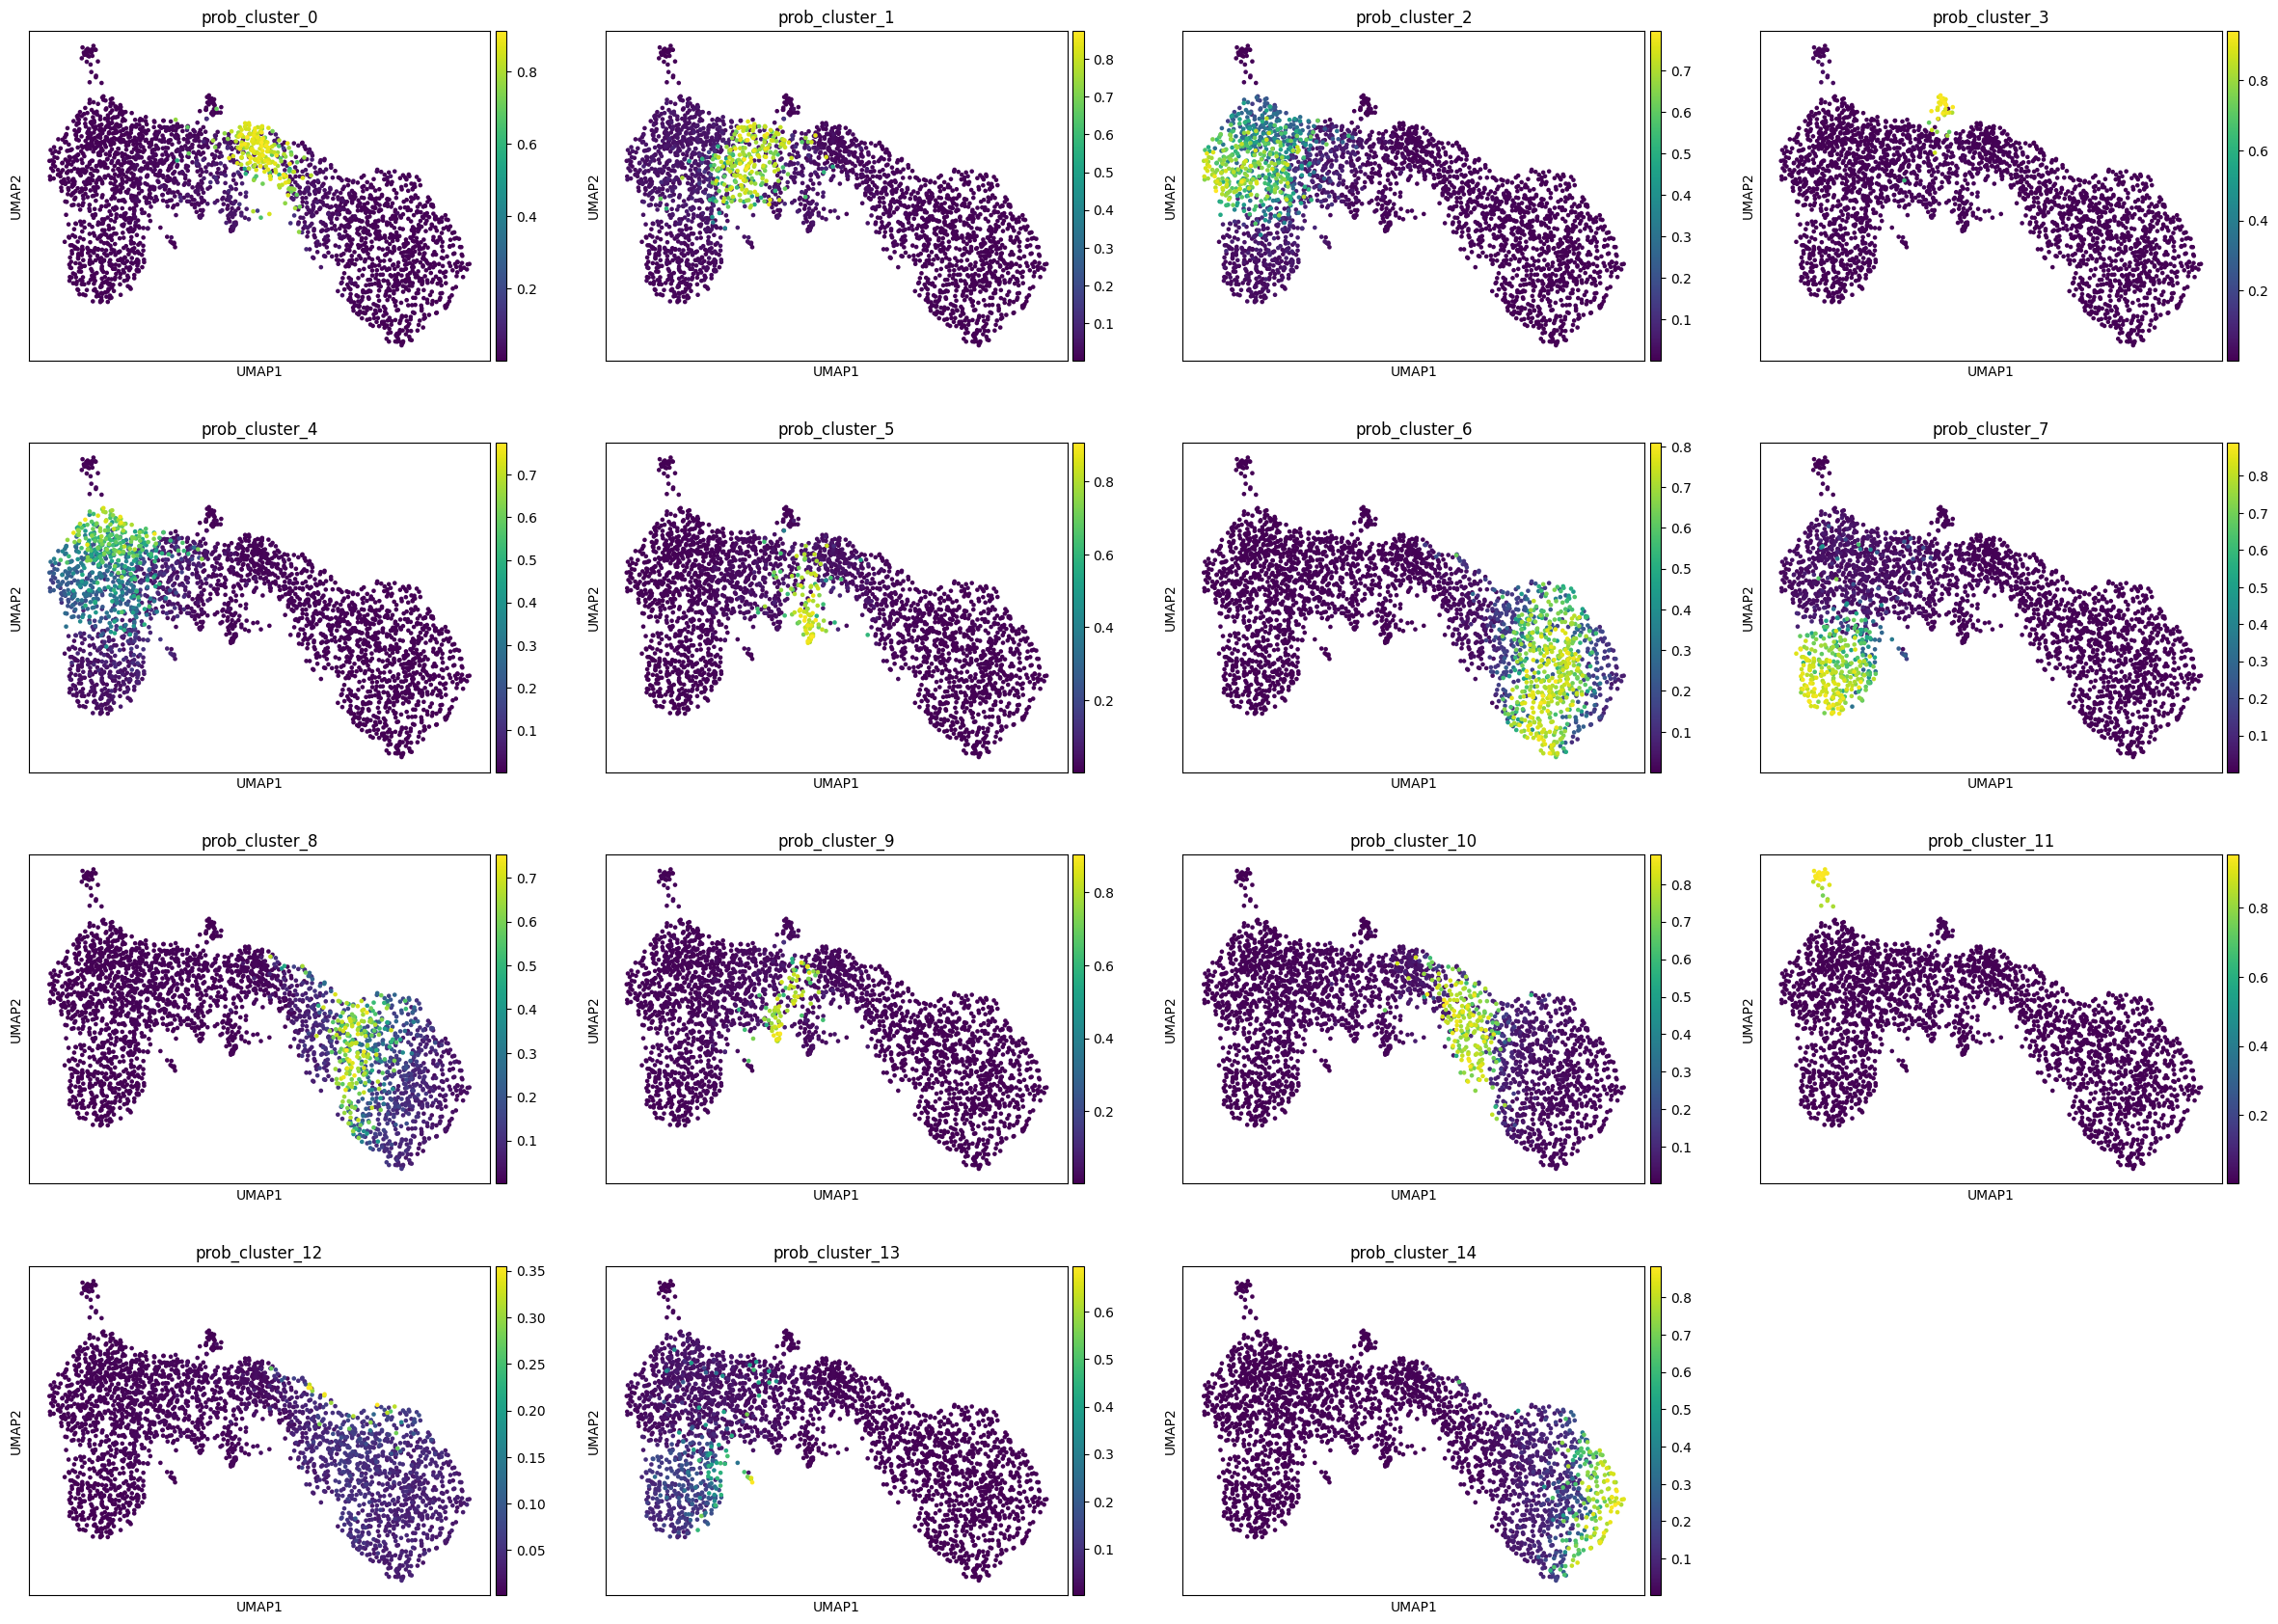

In [15]:
# Cluster probability visualisation
n_clusters = adata_stc.obsm['stc_probs'].shape[1]

for i in range(n_clusters):
    adata_stc.obs[f'prob_cluster_{i}'] = adata_stc.obsm['stc_probs'][:, i]

columns_to_plot = [f'prob_cluster_{i}' for i in range(n_clusters)]
sc.pl.umap(adata_stc, color=columns_to_plot, cmap='viridis', ncols=4)